In [1]:
# CPU allocation controls. Set CPU_LIST like "0-15" or "0,2,4" before executing if desired.
import os

CPU_LIST = None

def parse_cpu_list(spec):
    if spec is None or str(spec).strip() == "":
        return None
    cpus = []
    for raw_part in str(spec).split(","):
        part = raw_part.strip()
        if not part:
            continue
        if "-" in part:
            start, stop = (int(x) for x in part.split("-", 1))
            cpus.extend(range(start, stop + 1))
        else:
            cpus.append(int(part))
    return sorted(set(cpus))

requested_cpus = parse_cpu_list(CPU_LIST)
if requested_cpus is not None and hasattr(os, "sched_setaffinity"):
    os.sched_setaffinity(0, requested_cpus)
effective_cpus = sorted(os.sched_getaffinity(0)) if hasattr(os, "sched_getaffinity") else None
print(f"CPU_LIST requested={CPU_LIST!r}; effective={effective_cpus}")


CPU_LIST requested=None; effective=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111]


In [2]:
from pathlib import Path
import json

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "REPO_POLICY.md").exists():
    REPO_ROOT = Path.cwd().parent

CAMPAIGN_ROOT = (
    REPO_ROOT
    / "choi_covariance_cpu"
    / "cpu_data"
    / "complex_particle_choi_transfer"
    / "campaigns"
    / "Nx20_Ny20-24-30_DW1_dwtrunc1_a1-1-3_S10_cycles2Ny"
)
FIGURE_DIR = REPO_ROOT / "choi_covariance_cpu" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

gap_nan_sentinel = 10.0
alpha_values = [1.0, 3.0]
ny_values = [20, 24, 30]
colors = {20: "#1f77b4", 24: "#d62728", 30: "#2ca02c"}
markers = {20: "o", 24: "s", 30: "^"}

mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["CMU Sans Serif", "DejaVu Sans"],
        "font.size": 8,
        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "legend.fontsize": 7,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

print(f"campaign root: {CAMPAIGN_ROOT}")
print(f"NaN gap sentinel: {gap_nan_sentinel}")


campaign root: /home/abhuiyan/class_A_fermionic_adaptive_circuit/choi_covariance_cpu/cpu_data/complex_particle_choi_transfer/campaigns/Nx20_Ny20-24-30_DW1_dwtrunc1_a1-1-3_S10_cycles2Ny
NaN gap sentinel: 10.0


In [3]:
records = []
for run_dir in sorted((CAMPAIGN_ROOT / "runs").iterdir()):
    if not run_dir.is_dir():
        continue
    summary = json.loads((run_dir / "run_summary.json").read_text())
    alpha_1 = float(summary["alpha_1"])
    ny = int(summary["Ny"])
    if alpha_1 not in alpha_values or ny not in ny_values:
        continue
    with np.load(run_dir / "particle_choi_transfer_gap_vs_cycle.npz", allow_pickle=False) as data:
        cycles = np.asarray(data["cycles"], dtype=np.int64)
        gap = np.asarray(data["gap"], dtype=np.float64)
        stable = np.asarray(data["stable_at_cycle"], dtype=bool)
        finite_counts = np.asarray(data["finite_exponent_count"], dtype=np.int64)
    gap_plot = np.where(np.isfinite(gap), gap, gap_nan_sentinel)
    rms_gap = np.sqrt(np.mean(gap_plot**2, axis=0))
    finite_sample_count = np.sum(np.isfinite(gap), axis=0)
    sentinel_count = np.sum(~np.isfinite(gap), axis=0)
    records.append(
        {
            "alpha_1": alpha_1,
            "Ny": ny,
            "Nx": int(summary["Nx"]),
            "cycles": cycles,
            "rms_gap": rms_gap,
            "finite_sample_count": finite_sample_count,
            "sentinel_count": sentinel_count,
            "median_finite_exponent_count": np.median(finite_counts, axis=0),
            "stable_final": int(stable[:, -1].sum()),
            "run_dir": run_dir,
        }
    )

records = sorted(records, key=lambda row: (row["alpha_1"], row["Ny"]))
assert len(records) == len(alpha_values) * len(ny_values), f"loaded {len(records)} records"
print(f"loaded {len(records)} curves")
for row in records:
    print(
        f"alpha_1={row['alpha_1']:g}, Ny={row['Ny']}: "
        f"cycles={row['cycles'][0]}..{row['cycles'][-1]}, "
        f"stable_final={row['stable_final']}, "
        f"sentinel_final={int(row['sentinel_count'][-1])}"
    )


loaded 6 curves
alpha_1=1, Ny=20: cycles=1..40, stable_final=10, sentinel_final=0
alpha_1=1, Ny=24: cycles=1..48, stable_final=10, sentinel_final=0
alpha_1=1, Ny=30: cycles=1..60, stable_final=10, sentinel_final=0
alpha_1=3, Ny=20: cycles=1..40, stable_final=10, sentinel_final=10
alpha_1=3, Ny=24: cycles=1..48, stable_final=10, sentinel_final=10
alpha_1=3, Ny=30: cycles=1..60, stable_final=10, sentinel_final=10


TeX  NOT subset; don't know how to subset; dropped


saved /home/abhuiyan/class_A_fermionic_adaptive_circuit/choi_covariance_cpu/figures/gap_vs_cycle_nan_sentinel.png
saved /home/abhuiyan/class_A_fermionic_adaptive_circuit/choi_covariance_cpu/figures/gap_vs_cycle_nan_sentinel.pdf


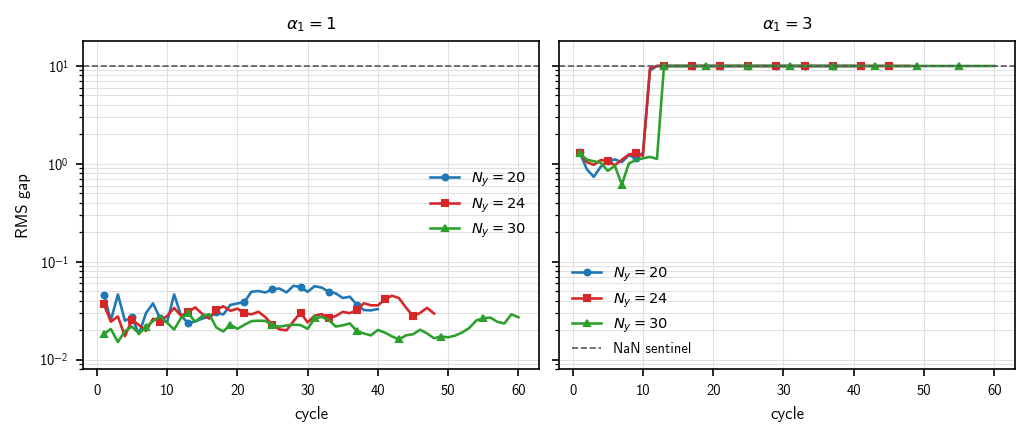

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(6.75, 2.8), sharey=True, constrained_layout=True)

for ax, alpha_1 in zip(axes, alpha_values):
    for row in records:
        if row["alpha_1"] != alpha_1:
            continue
        ny = row["Ny"]
        ax.plot(
            row["cycles"],
            row["rms_gap"],
            color=colors[ny],
            marker=markers[ny],
            markersize=2.8,
            linewidth=1.25,
            markevery=max(1, len(row["cycles"]) // 10),
            label=fr"$N_y={ny}$",
        )
    ax.axhline(gap_nan_sentinel, color="0.35", linewidth=0.8, linestyle="--", label="NaN sentinel" if alpha_1 == 3.0 else None)
    ax.set_yscale("log")
    ax.set_xlabel("cycle")
    ax.set_title(fr"$\alpha_1={alpha_1:g}$")
    ax.grid(True, which="both", color="0.88", linewidth=0.5)
    ax.set_ylim(8e-3, 1.8e1)

axes[0].set_ylabel("RMS gap")
axes[0].legend(frameon=False, loc="best")
axes[1].legend(frameon=False, loc="best")

png_path = FIGURE_DIR / "gap_vs_cycle_nan_sentinel.png"
pdf_path = FIGURE_DIR / "gap_vs_cycle_nan_sentinel.pdf"
fig.savefig(png_path, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
print(f"saved {png_path}")
print(f"saved {pdf_path}")
plt.show()


TeX  NOT subset; don't know how to subset; dropped


saved /home/abhuiyan/class_A_fermionic_adaptive_circuit/choi_covariance_cpu/figures/gap_vs_system_size_fixed_cycles_nan_sentinel.png
saved /home/abhuiyan/class_A_fermionic_adaptive_circuit/choi_covariance_cpu/figures/gap_vs_system_size_fixed_cycles_nan_sentinel.pdf


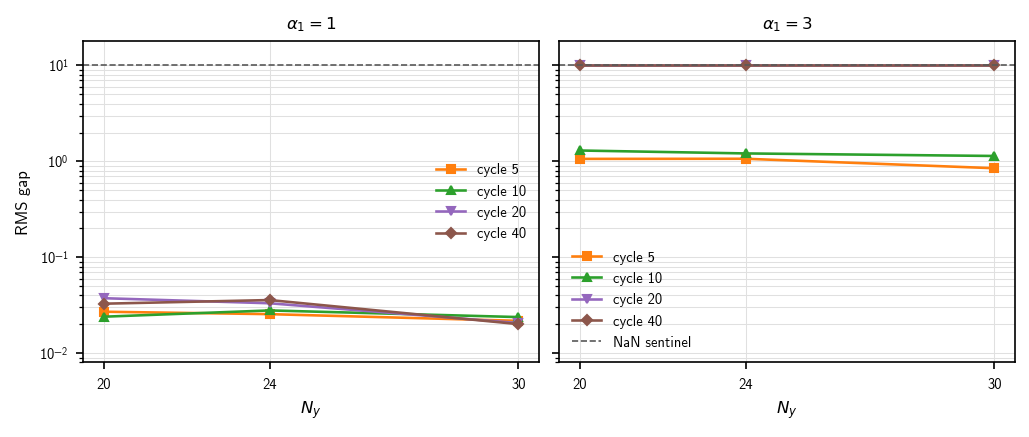

In [5]:
fixed_cycles = [5, 10, 20, 40]
cycle_colors = {
    5: "#ff7f0e",
    10: "#2ca02c",
    20: "#9467bd",
    40: "#8c564b",
}
cycle_markers = {5: "s", 10: "^", 20: "v", 40: "D"}

by_alpha_ny = {(row["alpha_1"], row["Ny"]): row for row in records}
fig, axes = plt.subplots(1, 2, figsize=(6.75, 2.8), sharey=True, constrained_layout=True)

for ax, alpha_1 in zip(axes, alpha_values):
    for cycle in fixed_cycles:
        rms_values = []
        for ny in ny_values:
            row = by_alpha_ny[(alpha_1, ny)]
            matches = np.where(row["cycles"] == cycle)[0]
            if matches.size != 1:
                raise ValueError(f"cycle {cycle} not found for alpha_1={alpha_1}, Ny={ny}")
            rms_values.append(float(row["rms_gap"][int(matches[0])]))
        ax.plot(
            ny_values,
            rms_values,
            color=cycle_colors[cycle],
            marker=cycle_markers[cycle],
            markersize=3.4,
            linewidth=1.25,
            label=fr"cycle {cycle}",
        )
    ax.axhline(gap_nan_sentinel, color="0.35", linewidth=0.8, linestyle="--", label="NaN sentinel" if alpha_1 == 3.0 else None)
    ax.set_yscale("log")
    ax.set_xlabel(r"$N_y$")
    ax.set_title(fr"$\alpha_1={alpha_1:g}$")
    ax.set_xticks(ny_values)
    ax.grid(True, which="both", color="0.88", linewidth=0.5)
    ax.set_ylim(8e-3, 1.8e1)

axes[0].set_ylabel("RMS gap")
axes[0].legend(frameon=False, loc="best")
axes[1].legend(frameon=False, loc="best")

system_png_path = FIGURE_DIR / "gap_vs_system_size_fixed_cycles_nan_sentinel.png"
system_pdf_path = FIGURE_DIR / "gap_vs_system_size_fixed_cycles_nan_sentinel.pdf"
fig.savefig(system_png_path, bbox_inches="tight")
fig.savefig(system_pdf_path, bbox_inches="tight")
print(f"saved {system_png_path}")
print(f"saved {system_pdf_path}")
plt.show()


TeX  NOT subset; don't know how to subset; dropped


saved /home/abhuiyan/class_A_fermionic_adaptive_circuit/choi_covariance_cpu/figures/alpha1_near_gap_eigenstate_xcut_y_mid.png
saved /home/abhuiyan/class_A_fermionic_adaptive_circuit/choi_covariance_cpu/figures/alpha1_near_gap_eigenstate_xcut_y_mid.pdf
Ny=20, mode=0: n=10, peak_x=5, peak_weight=0.498
Ny=20, mode=1: n=10, peak_x=15, peak_weight=0.631
Ny=20, mode=2: n=10, peak_x=15, peak_weight=0.630
Ny=24, mode=0: n=10, peak_x=5, peak_weight=0.391
Ny=24, mode=1: n=10, peak_x=15, peak_weight=0.756
Ny=24, mode=2: n=10, peak_x=15, peak_weight=0.828
Ny=30, mode=0: n=10, peak_x=5, peak_weight=0.381
Ny=30, mode=1: n=10, peak_x=15, peak_weight=0.606
Ny=30, mode=2: n=10, peak_x=15, peak_weight=0.712


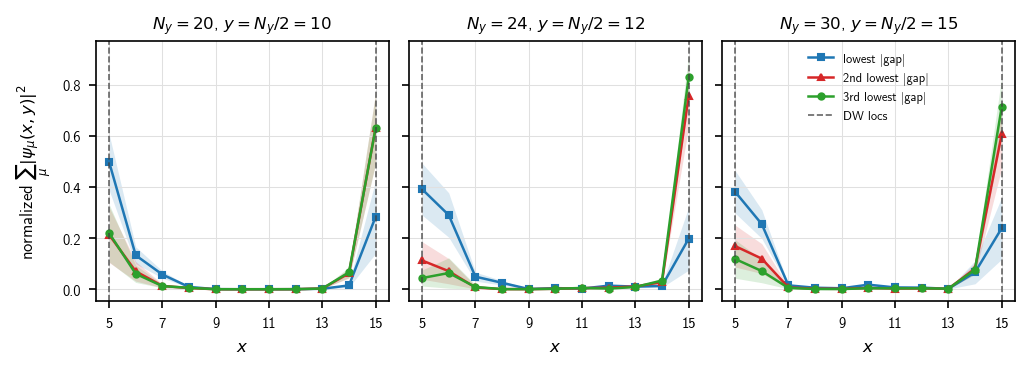

In [6]:
alpha_for_eigenstate_cut = 1.0
mode_slots = [0, 1, 2]
mode_labels = {0: "lowest |gap|", 1: "2nd lowest |gap|", 2: "3rd lowest |gap|"}
mode_colors = {0: "#1f77b4", 1: "#d62728", 2: "#2ca02c"}
dw_locs = [5, 15]
cut_rows = []

for row in records:
    if row["alpha_1"] != alpha_for_eigenstate_cut:
        continue
    run_dir = row["run_dir"]
    ny = row["Ny"]
    nx = row["Nx"]
    y_cut = ny // 2
    with np.load(run_dir / "particle_choi_transfer_final_eigenstates_near_gap.npz", allow_pickle=False) as data:
        eigenstates = np.asarray(data["eigenstates_near_gap"], dtype=np.complex128)
        valid_count = np.asarray(data["near_gap_valid_count_final"], dtype=np.int64)
        active_indices = np.asarray(data["active_top_layer_indices"], dtype=np.int64)
    mus = active_indices % 2
    xs = (active_indices // 2) % nx
    ys = active_indices // (2 * nx)
    x_values = np.arange(int(xs.min()), int(xs.max()) + 1)
    for mode in mode_slots:
        profiles = []
        for sample_idx in range(eigenstates.shape[0]):
            if valid_count[sample_idx] <= mode:
                continue
            vec = eigenstates[sample_idx, :, mode]
            density = np.abs(vec) ** 2
            cut = np.array([density[(xs == x) & (ys == y_cut)].sum() for x in x_values], dtype=float)
            norm = cut.sum()
            if np.isfinite(norm) and norm > 0:
                profiles.append(cut / norm)
        if profiles:
            profiles = np.asarray(profiles, dtype=float)
            cut_rows.append(
                {
                    "Ny": ny,
                    "Nx": nx,
                    "mode": mode,
                    "y_cut": y_cut,
                    "x_values": x_values,
                    "mean_profile": profiles.mean(axis=0),
                    "sem_profile": profiles.std(axis=0, ddof=1) / np.sqrt(profiles.shape[0]) if profiles.shape[0] > 1 else np.zeros_like(profiles[0]),
                    "n_profiles": profiles.shape[0],
                }
            )

fig, axes = plt.subplots(1, 3, figsize=(6.75, 2.35), sharey=True, constrained_layout=True)
for ax, ny in zip(axes, ny_values):
    rows_here = [item for item in cut_rows if item["Ny"] == ny]
    for item in sorted(rows_here, key=lambda z: z["mode"]):
        x = item["x_values"]
        mean = item["mean_profile"]
        sem = item["sem_profile"]
        mode = item["mode"]
        ax.plot(x, mean, color=mode_colors[mode], marker=cycle_markers.get(5 + 5*mode, "o"), markersize=3.0, linewidth=1.2, label=mode_labels[mode])
        ax.fill_between(x, np.maximum(mean - sem, 0), mean + sem, color=mode_colors[mode], alpha=0.16, linewidth=0)
    for dw_idx, dw in enumerate(dw_locs):
        ax.axvline(dw, color="0.25", linestyle="--", linewidth=0.8, alpha=0.8, label="DW locs" if dw_idx == 0 else None)
    ax.set_title(fr"$N_y={ny}$, $y=N_y/2={ny//2}$")
    ax.set_xlabel(r"$x$")
    ax.set_xticks(np.arange(dw_locs[0], dw_locs[1] + 1, 2))
    ax.grid(True, color="0.88", linewidth=0.5)
    ax.set_xlim(dw_locs[0] - 0.5, dw_locs[1] + 0.5)
axes[0].set_ylabel(r"normalized $\sum_\mu |\psi_\mu(x,y)|^2$")
axes[-1].legend(frameon=False, loc="best", fontsize=6)

cut_png_path = FIGURE_DIR / "alpha1_near_gap_eigenstate_xcut_y_mid.png"
cut_pdf_path = FIGURE_DIR / "alpha1_near_gap_eigenstate_xcut_y_mid.pdf"
fig.savefig(cut_png_path, bbox_inches="tight")
fig.savefig(cut_pdf_path, bbox_inches="tight")
print(f"saved {cut_png_path}")
print(f"saved {cut_pdf_path}")
for item in cut_rows:
    peak_x = int(item["x_values"][int(np.argmax(item["mean_profile"]))])
    print(f"Ny={item['Ny']}, mode={item['mode']}: n={item['n_profiles']}, peak_x={peak_x}, peak_weight={item['mean_profile'].max():.3f}")
plt.show()


TeX  NOT subset; don't know how to subset; dropped


saved /home/abhuiyan/class_A_fermionic_adaptive_circuit/choi_covariance_cpu/figures/alpha1_near_gap_eigenstate_density_heatmap_grid.png
saved /home/abhuiyan/class_A_fermionic_adaptive_circuit/choi_covariance_cpu/figures/alpha1_near_gap_eigenstate_density_heatmap_grid.pdf
rank=1, Ny=20: n=10, mean_abs_log_sv=0.0284476, peak=(x=5, y=13), peak_weight=0.05126
rank=1, Ny=24: n=10, mean_abs_log_sv=0.0269998, peak=(x=5, y=22), peak_weight=0.05694
rank=1, Ny=30: n=10, mean_abs_log_sv=0.0249253, peak=(x=5, y=6), peak_weight=0.03301
rank=2, Ny=20: n=10, mean_abs_log_sv=0.0650867, peak=(x=15, y=17), peak_weight=0.08424
rank=2, Ny=24: n=10, mean_abs_log_sv=0.0575794, peak=(x=15, y=18), peak_weight=0.06936
rank=2, Ny=30: n=10, mean_abs_log_sv=0.0433635, peak=(x=15, y=28), peak_weight=0.07154
rank=3, Ny=20: n=10, mean_abs_log_sv=0.128482, peak=(x=15, y=17), peak_weight=0.08227
rank=3, Ny=24: n=10, mean_abs_log_sv=0.0900174, peak=(x=15, y=18), peak_weight=0.0746
rank=3, Ny=30: n=10, mean_abs_log_sv=0

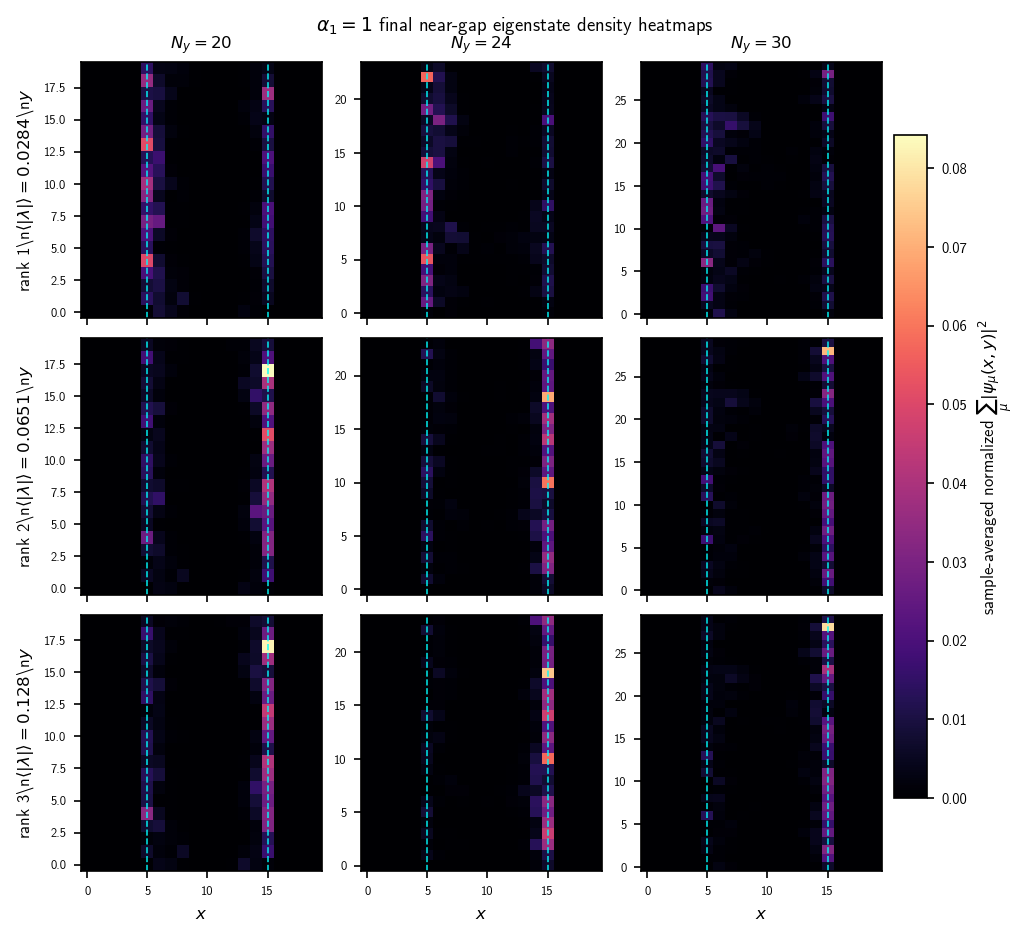

In [7]:
alpha_for_heatmap = 1.0
heatmap_modes = [0, 1, 2]
heatmap_rows = []

for row in records:
    if row["alpha_1"] != alpha_for_heatmap:
        continue
    run_dir = row["run_dir"]
    nx = row["Nx"]
    ny = row["Ny"]
    with np.load(run_dir / "particle_choi_transfer_final_eigenstates_near_gap.npz", allow_pickle=False) as data:
        eigenstates = np.asarray(data["eigenstates_near_gap"], dtype=np.complex128)
        exponents = np.asarray(data["eigenstate_exponents"], dtype=np.float64)
        a_eigs = np.asarray(data["eigenstate_a_eigenvalues"], dtype=np.float64)
        valid_count = np.asarray(data["near_gap_valid_count_final"], dtype=np.int64)
        active_indices = np.asarray(data["active_top_layer_indices"], dtype=np.int64)
    xs = (active_indices // 2) % nx
    ys = active_indices // (2 * nx)
    for mode in heatmap_modes:
        maps = []
        abs_exps = []
        abs_a = []
        for sample_idx in range(eigenstates.shape[0]):
            if valid_count[sample_idx] <= mode:
                continue
            vec = eigenstates[sample_idx, :, mode]
            density_active = np.abs(vec) ** 2
            density_xy = np.zeros((nx, ny), dtype=float)
            np.add.at(density_xy, (xs, ys), density_active)
            norm = density_xy.sum()
            if np.isfinite(norm) and norm > 0:
                maps.append(density_xy / norm)
                abs_exps.append(abs(float(exponents[sample_idx, mode])))
                abs_a.append(abs(float(a_eigs[sample_idx, mode])))
        if maps:
            maps = np.asarray(maps, dtype=float)
            heatmap_rows.append(
                {
                    "Ny": ny,
                    "Nx": nx,
                    "mode": mode,
                    "density": maps.mean(axis=0),
                    "n_profiles": maps.shape[0],
                    "mean_abs_exponent": float(np.mean(abs_exps)),
                    "mean_abs_a_eigenvalue": float(np.mean(abs_a)),
                }
            )

global_vmax = max(float(item["density"].max()) for item in heatmap_rows)
fig, axes = plt.subplots(3, 3, figsize=(6.75, 6.0), sharex=True, constrained_layout=True)

last_im = None
for col, ny in enumerate(ny_values):
    for row_idx, mode in enumerate(heatmap_modes):
        ax = axes[row_idx, col]
        item = next(entry for entry in heatmap_rows if entry["Ny"] == ny and entry["mode"] == mode)
        density = item["density"]
        last_im = ax.imshow(
            density.T,
            origin="lower",
            aspect="auto",
            interpolation="nearest",
            extent=(-0.5, item["Nx"] - 0.5, -0.5, item["Ny"] - 0.5),
            cmap="magma",
            vmin=0.0,
            vmax=global_vmax,
        )
        for dw_idx, dw in enumerate(dw_locs):
            ax.axvline(dw, color="cyan", linestyle="--", linewidth=0.8, alpha=0.85)
        if row_idx == 0:
            ax.set_title(fr"$N_y={ny}$")
        if col == 0:
            ax.set_ylabel(
                fr"rank {mode + 1}\n$\langle |\lambda| \rangle={item['mean_abs_exponent']:.3g}$\n$y$"
            )
        if row_idx == len(heatmap_modes) - 1:
            ax.set_xlabel(r"$x$")
        ax.set_xlim(-0.5, item["Nx"] - 0.5)
        ax.set_ylim(-0.5, item["Ny"] - 0.5)
        ax.tick_params(labelsize=6)

cbar = fig.colorbar(last_im, ax=axes.ravel().tolist(), shrink=0.82, pad=0.015)
cbar.set_label(r"sample-averaged normalized $\sum_\mu |\psi_\mu(x,y)|^2$")
fig.suptitle(r"$\alpha_1=1$ final near-gap eigenstate density heatmaps", y=1.015, fontsize=9)

heatmap_png_path = FIGURE_DIR / "alpha1_near_gap_eigenstate_density_heatmap_grid.png"
heatmap_pdf_path = FIGURE_DIR / "alpha1_near_gap_eigenstate_density_heatmap_grid.pdf"
fig.savefig(heatmap_png_path, bbox_inches="tight")
fig.savefig(heatmap_pdf_path, bbox_inches="tight")
print(f"saved {heatmap_png_path}")
print(f"saved {heatmap_pdf_path}")
for item in sorted(heatmap_rows, key=lambda entry: (entry["mode"], entry["Ny"])):
    peak = np.unravel_index(int(np.argmax(item["density"])), item["density"].shape)
    print(
        f"rank={item['mode'] + 1}, Ny={item['Ny']}: n={item['n_profiles']}, "
        f"mean_abs_log_sv={item['mean_abs_exponent']:.6g}, peak=(x={peak[0]}, y={peak[1]}), "
        f"peak_weight={item['density'][peak]:.4g}"
    )
plt.show()


TeX  NOT subset; don't know how to subset; dropped


saved /home/abhuiyan/class_A_fermionic_adaptive_circuit/choi_covariance_cpu/figures/alpha1_near_gap_eigenstate_density_heatmap_grid_postavg_norm.png
saved /home/abhuiyan/class_A_fermionic_adaptive_circuit/choi_covariance_cpu/figures/alpha1_near_gap_eigenstate_density_heatmap_grid_postavg_norm.pdf
rank=1, Ny=20: n=10, mean_raw_norm=1, peak=(x=5, y=13), peak_weight=0.05126, max_diff_from_norm_then_avg=2.082e-17
rank=2, Ny=20: n=10, mean_raw_norm=1, peak=(x=15, y=17), peak_weight=0.08424, max_diff_from_norm_then_avg=2.776e-17
rank=3, Ny=20: n=10, mean_raw_norm=1, peak=(x=15, y=17), peak_weight=0.08227, max_diff_from_norm_then_avg=2.082e-17
rank=1, Ny=24: n=10, mean_raw_norm=1, peak=(x=5, y=22), peak_weight=0.05694, max_diff_from_norm_then_avg=1.388e-17
rank=2, Ny=24: n=10, mean_raw_norm=1, peak=(x=15, y=18), peak_weight=0.06936, max_diff_from_norm_then_avg=1.388e-17
rank=3, Ny=24: n=10, mean_raw_norm=1, peak=(x=15, y=18), peak_weight=0.0746, max_diff_from_norm_then_avg=2.776e-17
rank=1, N

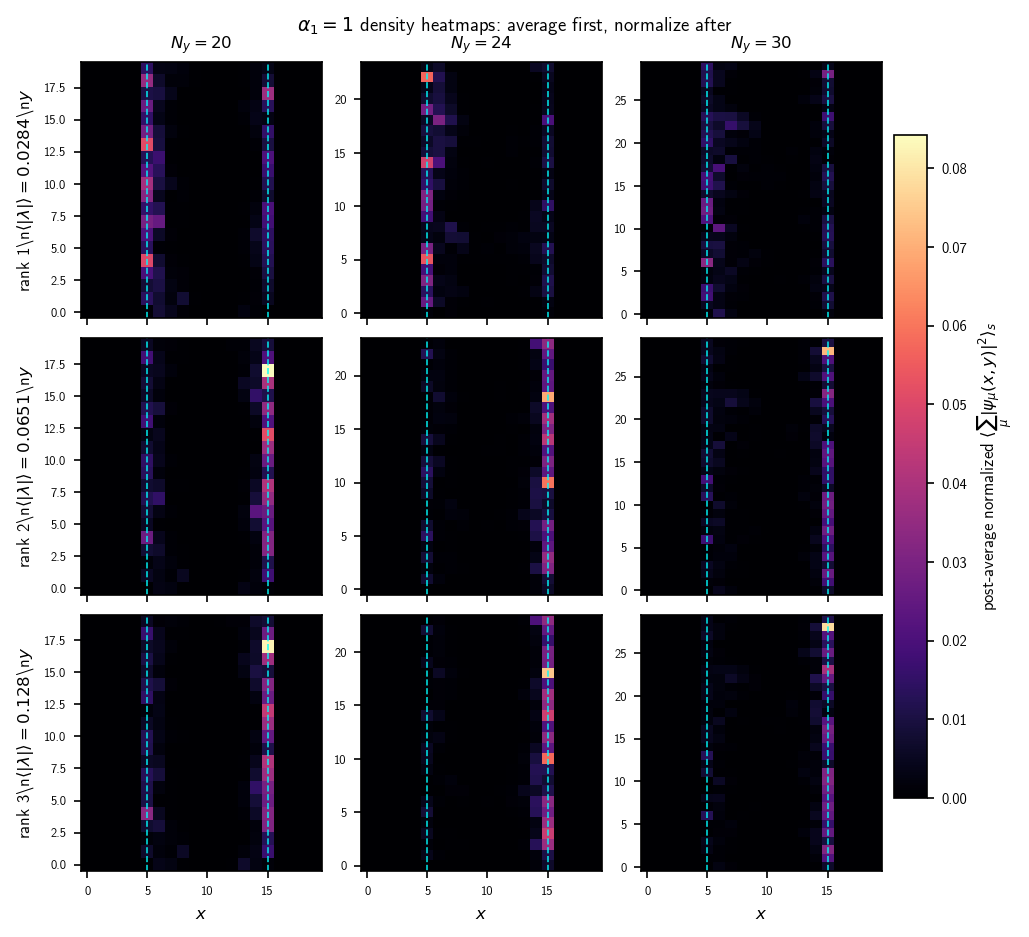

In [8]:
alpha_for_heatmap_postavg = 1.0
heatmap_postavg_rows = []

for row in records:
    if row["alpha_1"] != alpha_for_heatmap_postavg:
        continue
    run_dir = row["run_dir"]
    nx = row["Nx"]
    ny = row["Ny"]
    with np.load(run_dir / "particle_choi_transfer_final_eigenstates_near_gap.npz", allow_pickle=False) as data:
        eigenstates = np.asarray(data["eigenstates_near_gap"], dtype=np.complex128)
        exponents = np.asarray(data["eigenstate_exponents"], dtype=np.float64)
        a_eigs = np.asarray(data["eigenstate_a_eigenvalues"], dtype=np.float64)
        valid_count = np.asarray(data["near_gap_valid_count_final"], dtype=np.int64)
        active_indices = np.asarray(data["active_top_layer_indices"], dtype=np.int64)
    xs = (active_indices // 2) % nx
    ys = active_indices // (2 * nx)
    for mode in heatmap_modes:
        raw_maps = []
        raw_norms = []
        abs_exps = []
        abs_a = []
        for sample_idx in range(eigenstates.shape[0]):
            if valid_count[sample_idx] <= mode:
                continue
            vec = eigenstates[sample_idx, :, mode]
            density_active = np.abs(vec) ** 2
            density_xy = np.zeros((nx, ny), dtype=float)
            np.add.at(density_xy, (xs, ys), density_active)
            raw_norm = float(density_xy.sum())
            if np.isfinite(raw_norm) and raw_norm > 0:
                raw_maps.append(density_xy)
                raw_norms.append(raw_norm)
                abs_exps.append(abs(float(exponents[sample_idx, mode])))
                abs_a.append(abs(float(a_eigs[sample_idx, mode])))
        if raw_maps:
            raw_maps = np.asarray(raw_maps, dtype=float)
            mean_raw = raw_maps.mean(axis=0)
            mean_raw_norm = float(mean_raw.sum())
            density = mean_raw / mean_raw_norm
            heatmap_postavg_rows.append(
                {
                    "Ny": ny,
                    "Nx": nx,
                    "mode": mode,
                    "density": density,
                    "n_profiles": raw_maps.shape[0],
                    "mean_raw_norm": float(np.mean(raw_norms)),
                    "mean_abs_exponent": float(np.mean(abs_exps)),
                    "mean_abs_a_eigenvalue": float(np.mean(abs_a)),
                }
            )

postavg_vmax = max(float(item["density"].max()) for item in heatmap_postavg_rows)
fig, axes = plt.subplots(3, 3, figsize=(6.75, 6.0), sharex=True, constrained_layout=True)

last_im = None
for col, ny in enumerate(ny_values):
    for row_idx, mode in enumerate(heatmap_modes):
        ax = axes[row_idx, col]
        item = next(entry for entry in heatmap_postavg_rows if entry["Ny"] == ny and entry["mode"] == mode)
        density = item["density"]
        last_im = ax.imshow(
            density.T,
            origin="lower",
            aspect="auto",
            interpolation="nearest",
            extent=(-0.5, item["Nx"] - 0.5, -0.5, item["Ny"] - 0.5),
            cmap="magma",
            vmin=0.0,
            vmax=postavg_vmax,
        )
        for dw in dw_locs:
            ax.axvline(dw, color="cyan", linestyle="--", linewidth=0.8, alpha=0.85)
        if row_idx == 0:
            ax.set_title(fr"$N_y={ny}$")
        if col == 0:
            ax.set_ylabel(
                fr"rank {mode + 1}\n$\langle |\lambda| \rangle={item['mean_abs_exponent']:.3g}$\n$y$"
            )
        if row_idx == len(heatmap_modes) - 1:
            ax.set_xlabel(r"$x$")
        ax.set_xlim(-0.5, item["Nx"] - 0.5)
        ax.set_ylim(-0.5, item["Ny"] - 0.5)
        ax.tick_params(labelsize=6)

cbar = fig.colorbar(last_im, ax=axes.ravel().tolist(), shrink=0.82, pad=0.015)
cbar.set_label(r"post-average normalized $\langle\sum_\mu |\psi_\mu(x,y)|^2\rangle_s$")
fig.suptitle(r"$\alpha_1=1$ density heatmaps: average first, normalize after", y=1.015, fontsize=9)

postavg_png_path = FIGURE_DIR / "alpha1_near_gap_eigenstate_density_heatmap_grid_postavg_norm.png"
postavg_pdf_path = FIGURE_DIR / "alpha1_near_gap_eigenstate_density_heatmap_grid_postavg_norm.pdf"
fig.savefig(postavg_png_path, bbox_inches="tight")
fig.savefig(postavg_pdf_path, bbox_inches="tight")
print(f"saved {postavg_png_path}")
print(f"saved {postavg_pdf_path}")

max_diff = 0.0
for item in heatmap_postavg_rows:
    old = next(entry for entry in heatmap_rows if entry["Ny"] == item["Ny"] and entry["mode"] == item["mode"])
    diff = float(np.max(np.abs(item["density"] - old["density"])))
    max_diff = max(max_diff, diff)
    peak = np.unravel_index(int(np.argmax(item["density"])), item["density"].shape)
    print(
        f"rank={item['mode'] + 1}, Ny={item['Ny']}: n={item['n_profiles']}, "
        f"mean_raw_norm={item['mean_raw_norm']:.12g}, peak=(x={peak[0]}, y={peak[1]}), "
        f"peak_weight={item['density'][peak]:.4g}, max_diff_from_norm_then_avg={diff:.3e}"
    )
print(f"global max difference from normalize-then-average heatmap: {max_diff:.3e}")
plt.show()


In [9]:
print("Sentinel summary by curve:")
for row in records:
    sentinel_cycles = row["cycles"][row["sentinel_count"] > 0]
    first = int(sentinel_cycles[0]) if sentinel_cycles.size else None
    final = int(row["sentinel_count"][-1])
    median_finite_final = float(row["median_finite_exponent_count"][-1])
    print(
        f"alpha_1={row['alpha_1']:g}, Ny={row['Ny']}: "
        f"first sentinel cycle={first}, final sentinel samples={final}/10, "
        f"median final finite exponent count={median_finite_final:g}"
    )

print("\nSentinel counts at fixed system-size cycles:")
for row in records:
    counts = []
    for cycle in fixed_cycles:
        idx = int(np.where(row["cycles"] == cycle)[0][0])
        counts.append(f"c{cycle}={int(row['sentinel_count'][idx])}/10")
    print(f"alpha_1={row['alpha_1']:g}, Ny={row['Ny']}: " + ", ".join(counts))


Sentinel summary by curve:
alpha_1=1, Ny=20: first sentinel cycle=None, final sentinel samples=0/10, median final finite exponent count=8
alpha_1=1, Ny=24: first sentinel cycle=None, final sentinel samples=0/10, median final finite exponent count=8
alpha_1=1, Ny=30: first sentinel cycle=None, final sentinel samples=0/10, median final finite exponent count=8
alpha_1=3, Ny=20: first sentinel cycle=11, final sentinel samples=10/10, median final finite exponent count=0
alpha_1=3, Ny=24: first sentinel cycle=11, final sentinel samples=10/10, median final finite exponent count=0
alpha_1=3, Ny=30: first sentinel cycle=13, final sentinel samples=10/10, median final finite exponent count=0

Sentinel counts at fixed system-size cycles:
alpha_1=1, Ny=20: c5=0/10, c10=0/10, c20=0/10, c40=0/10
alpha_1=1, Ny=24: c5=0/10, c10=0/10, c20=0/10, c40=0/10
alpha_1=1, Ny=30: c5=0/10, c10=0/10, c20=0/10, c40=0/10
alpha_1=3, Ny=20: c5=0/10, c10=0/10, c20=10/10, c40=10/10
alpha_1=3, Ny=24: c5=0/10, c10=0/10, c